In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
import warnings
warnings.filterwarnings("ignore")

train_df = pd.read_csv("https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/Vitamin_deficiency_train.csv")
test_df = pd.read_csv("https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/Vitamin_deficiency_test.csv")


In [34]:
data = train_df

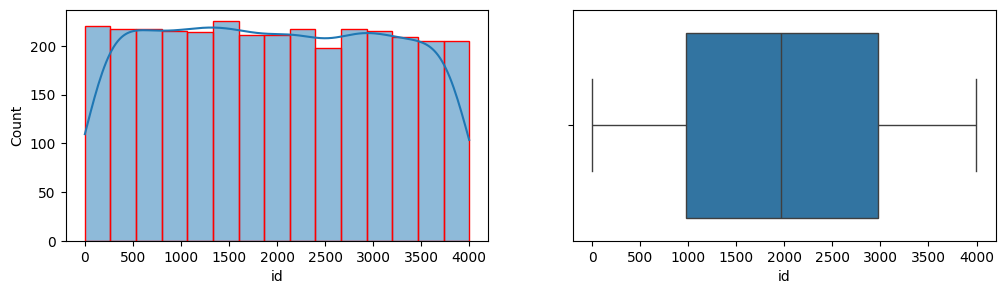

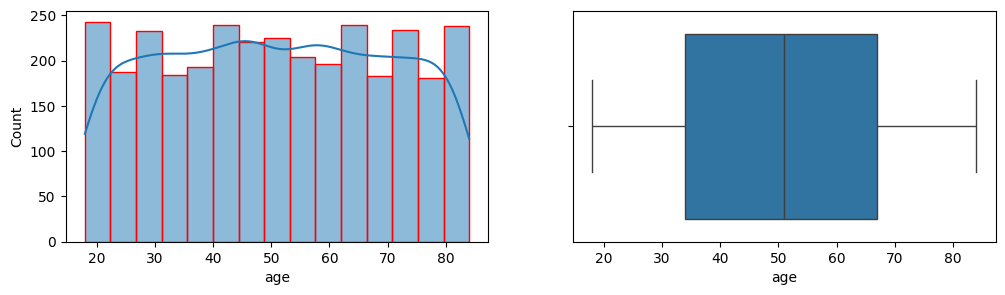

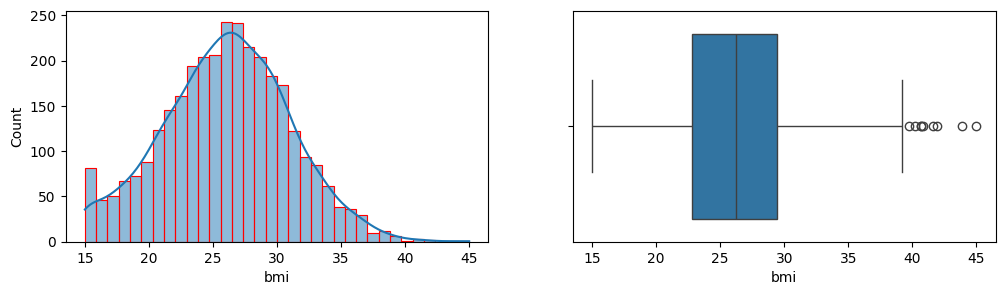

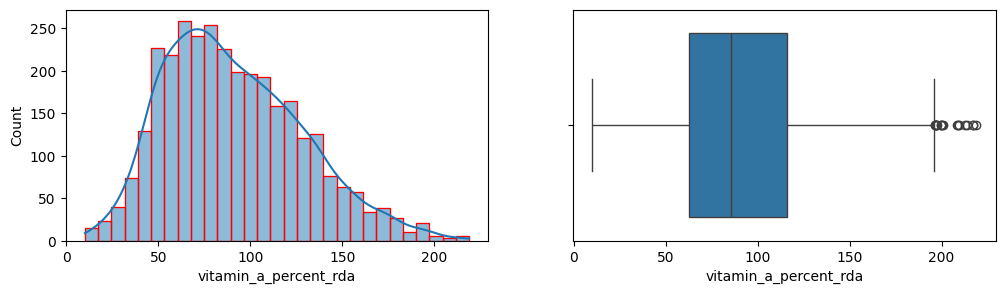

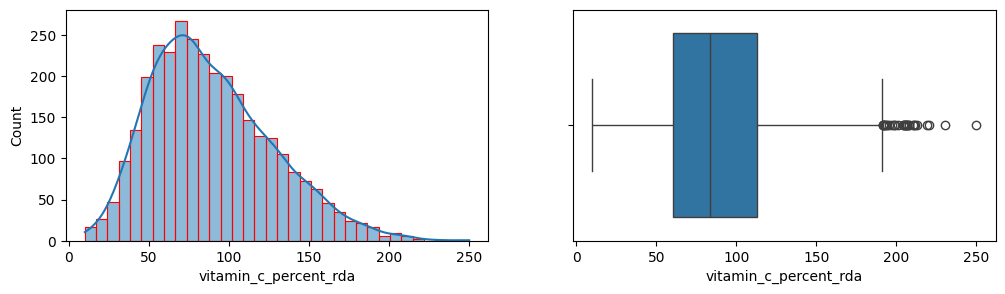

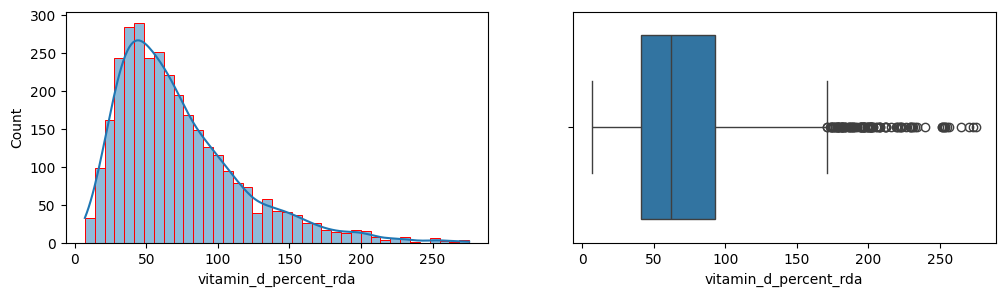

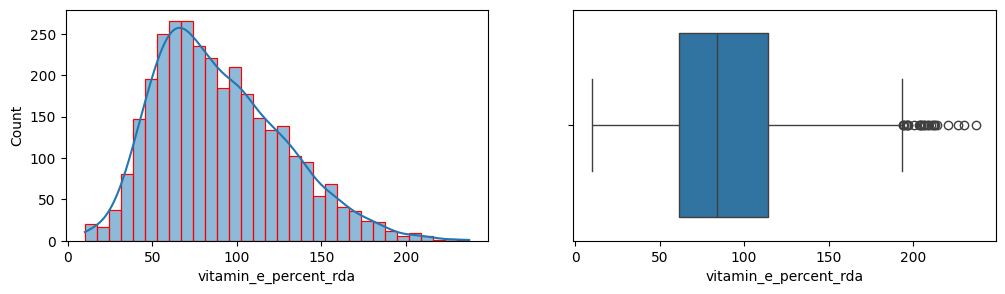

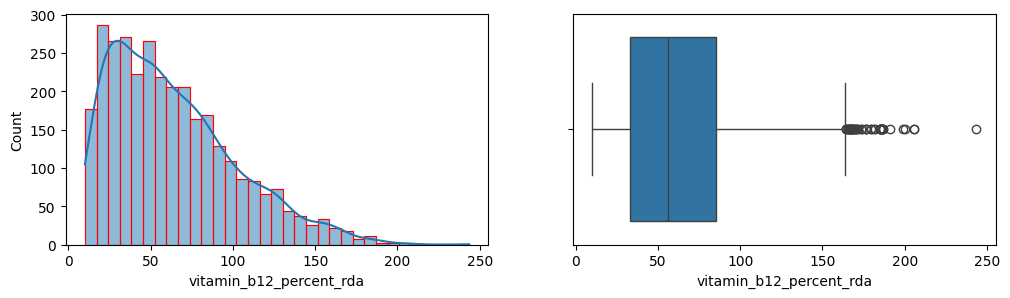

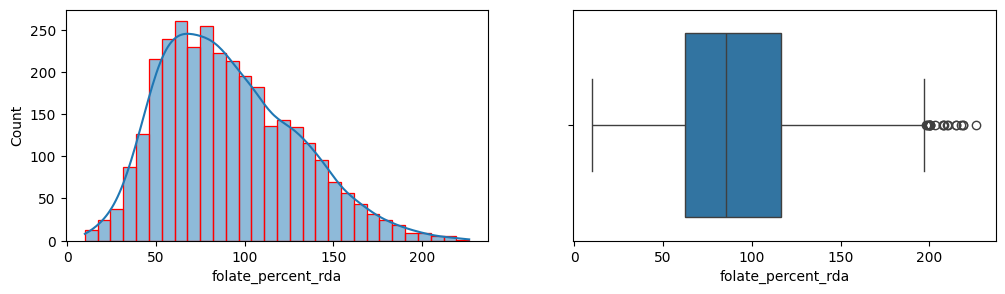

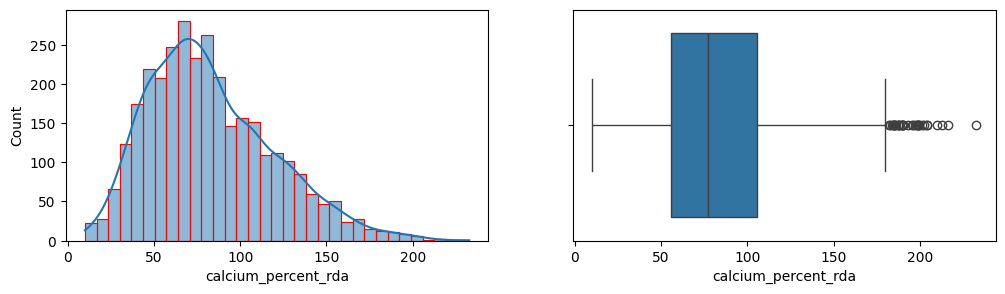

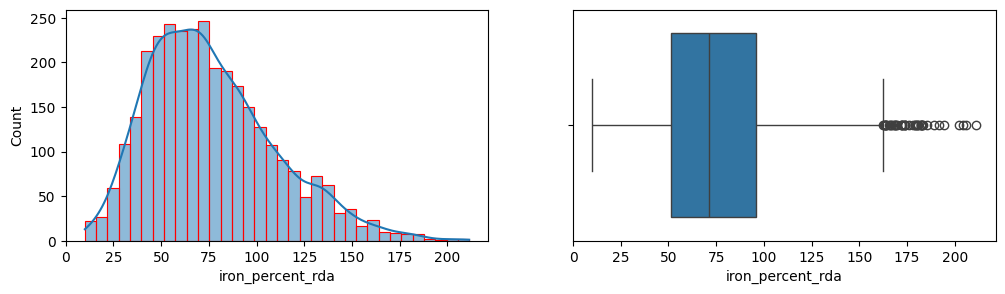

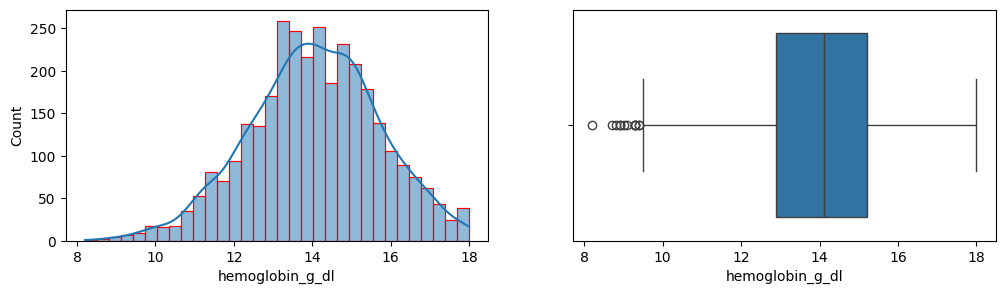

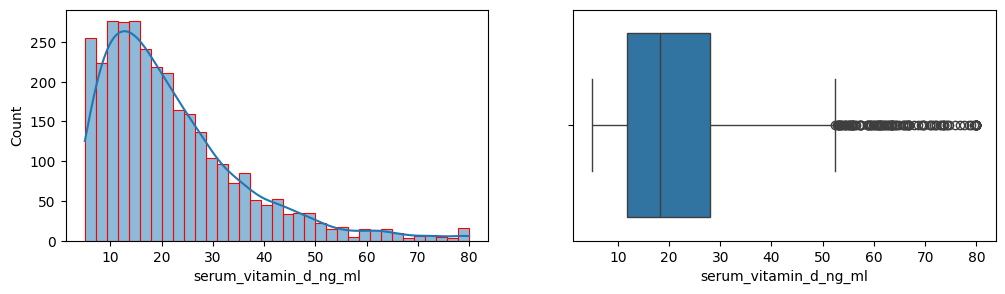

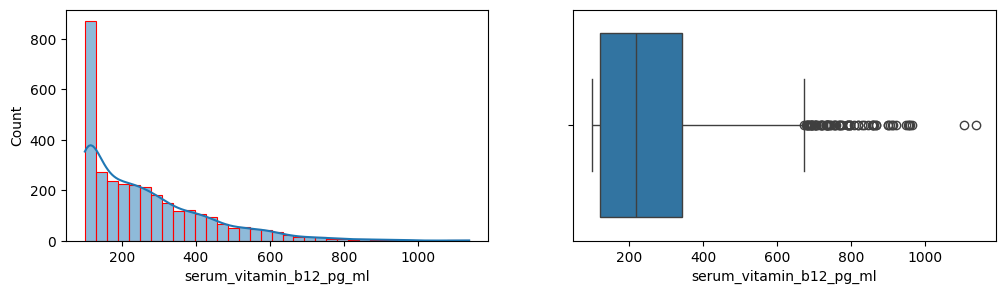

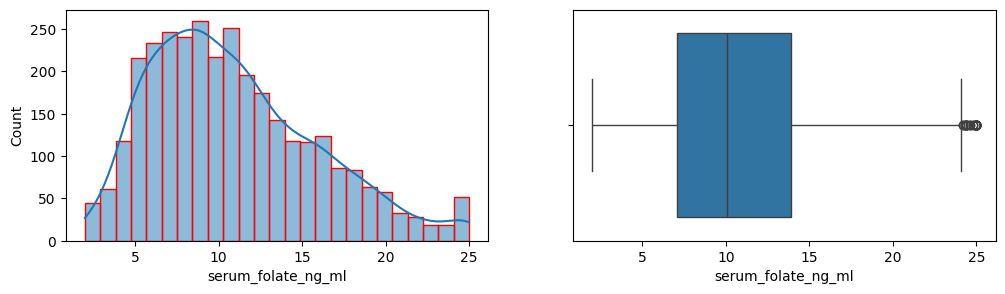

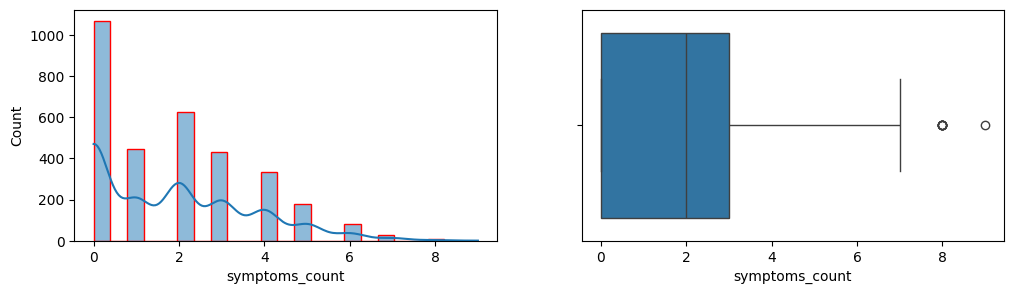

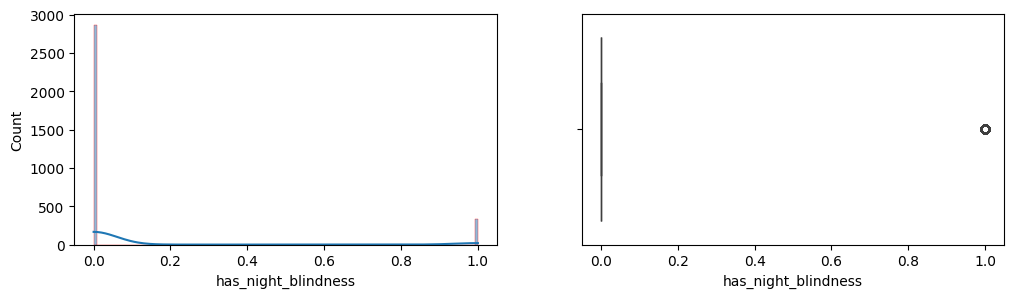

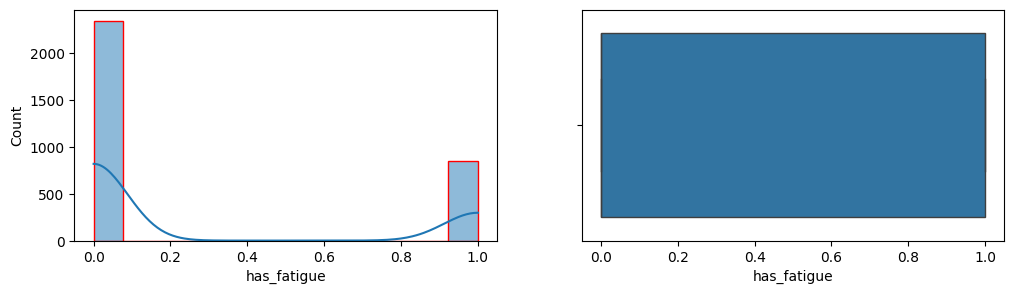

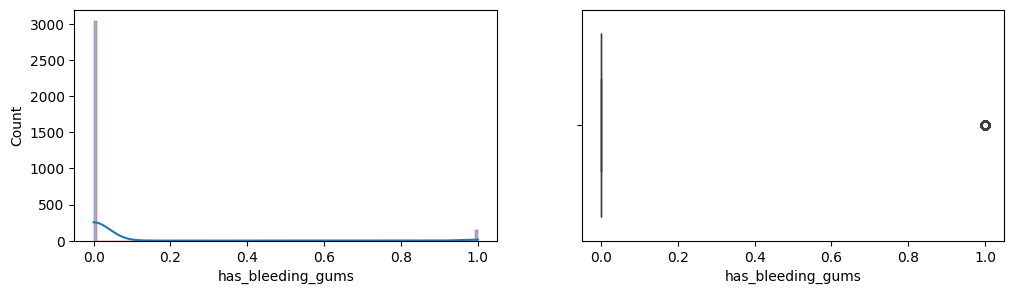

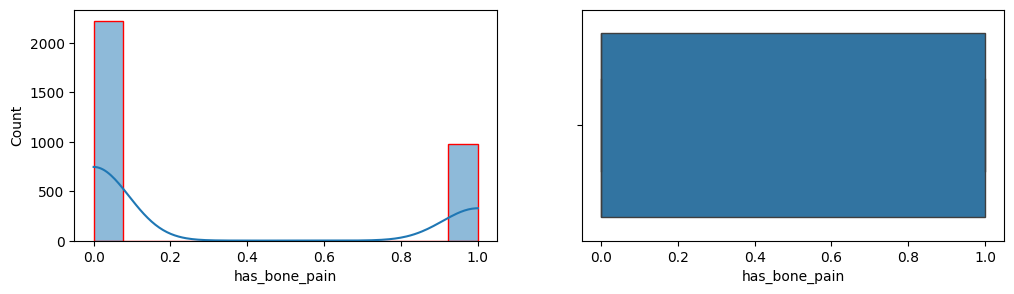

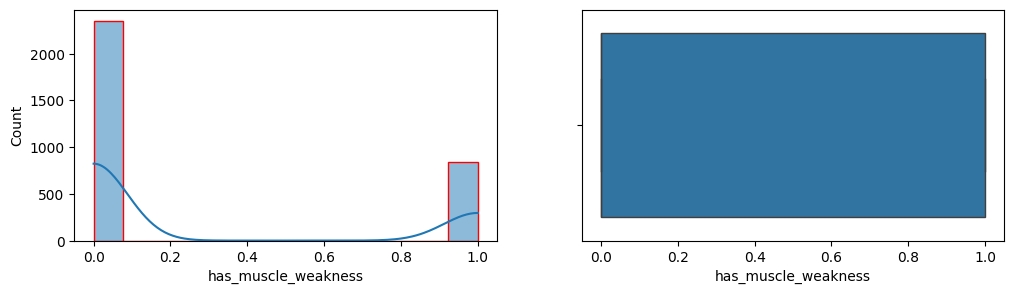

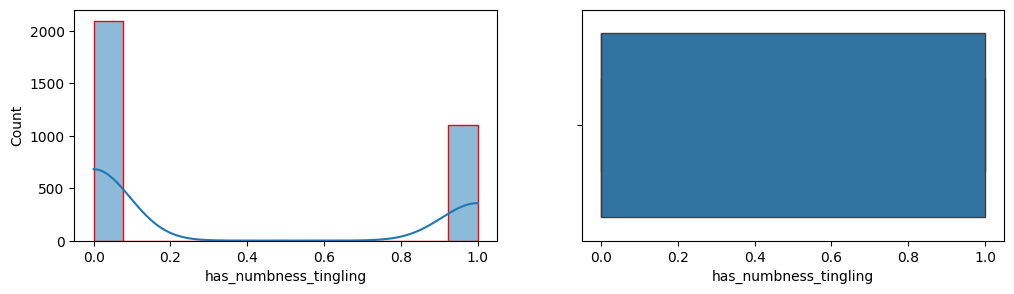

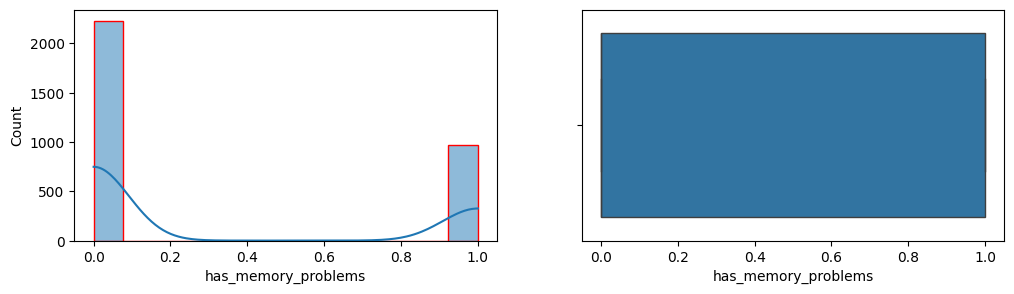

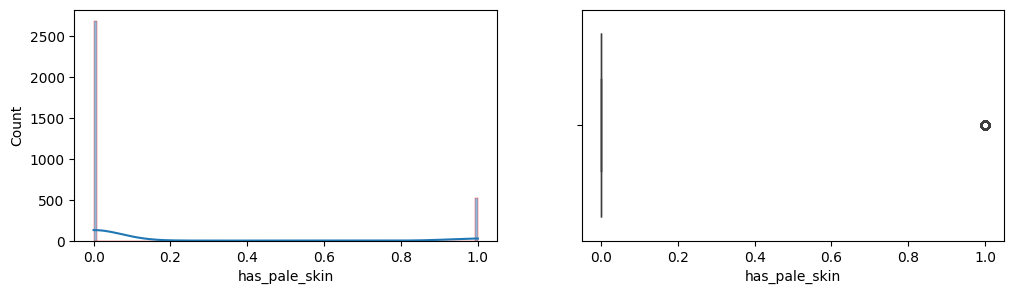

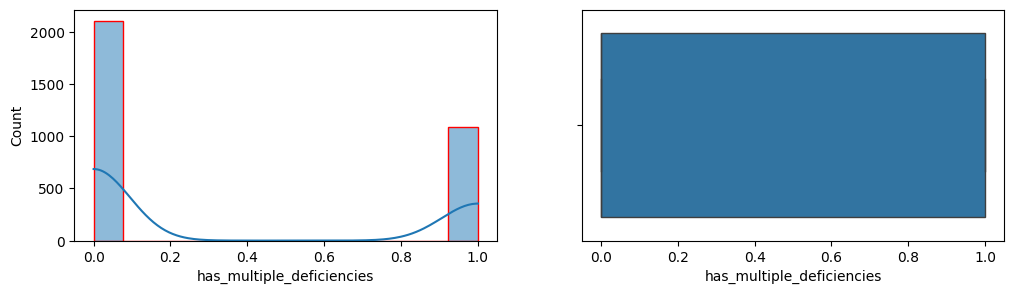

In [35]:
import matplotlib.pyplot as plt 
import seaborn as sns

for i in data.columns:
  if data[i].dtype == 'float64' or data[i].dtype == 'int64':
    plt.figure(figsize = (12,3)) 
    plt.subplot(1,2,1) 
    sns.histplot(data = data, x = i, kde = True, edgecolor = 'red' )
    plt.subplot(1,2,2) 
    sns.boxplot(data = data, x = i)

In [36]:
train_df.drop(columns = ['symptoms_list'], inplace = True)
test_df.drop(columns = ['symptoms_list'], inplace = True)

In [37]:
train_df.isna().sum()

id                              0
age                             0
gender                          0
bmi                             0
smoking_status                  0
alcohol_consumption          1020
exercise_level                  0
diet_type                       0
sun_exposure                    0
income_level                    0
latitude_region                 0
vitamin_a_percent_rda           0
vitamin_c_percent_rda           0
vitamin_d_percent_rda           0
vitamin_e_percent_rda           0
vitamin_b12_percent_rda         0
folate_percent_rda              0
calcium_percent_rda             0
iron_percent_rda                0
hemoglobin_g_dl                 0
serum_vitamin_d_ng_ml           0
serum_vitamin_b12_pg_ml         0
serum_folate_ng_ml              0
symptoms_count                  0
has_night_blindness             0
has_fatigue                     0
has_bleeding_gums               0
has_bone_pain                   0
has_muscle_weakness             0
has_numbness_t

In [38]:
alcohol_mode = train_df['alcohol_consumption'].mode()[0]
train_df['alcohol_consumption'] = train_df['alcohol_consumption'].fillna(alcohol_mode)

In [39]:
train_df.isna().sum()

id                           0
age                          0
gender                       0
bmi                          0
smoking_status               0
alcohol_consumption          0
exercise_level               0
diet_type                    0
sun_exposure                 0
income_level                 0
latitude_region              0
vitamin_a_percent_rda        0
vitamin_c_percent_rda        0
vitamin_d_percent_rda        0
vitamin_e_percent_rda        0
vitamin_b12_percent_rda      0
folate_percent_rda           0
calcium_percent_rda          0
iron_percent_rda             0
hemoglobin_g_dl              0
serum_vitamin_d_ng_ml        0
serum_vitamin_b12_pg_ml      0
serum_folate_ng_ml           0
symptoms_count               0
has_night_blindness          0
has_fatigue                  0
has_bleeding_gums            0
has_bone_pain                0
has_muscle_weakness          0
has_numbness_tingling        0
has_memory_problems          0
has_pale_skin                0
disease_

In [40]:
alcohol_mode_for_test_df = test_df['alcohol_consumption'].mode()[0]
test_df['alcohol_consumption'] = test_df['alcohol_consumption'].fillna(alcohol_mode_for_test_df)


In [41]:
test_df.isna().sum()

id                           0
age                          0
gender                       0
bmi                          0
smoking_status               0
alcohol_consumption          0
exercise_level               0
diet_type                    0
sun_exposure                 0
income_level                 0
latitude_region              0
vitamin_a_percent_rda        0
vitamin_c_percent_rda        0
vitamin_d_percent_rda        0
vitamin_e_percent_rda        0
vitamin_b12_percent_rda      0
folate_percent_rda           0
calcium_percent_rda          0
iron_percent_rda             0
hemoglobin_g_dl              0
serum_vitamin_d_ng_ml        0
serum_vitamin_b12_pg_ml      0
serum_folate_ng_ml           0
symptoms_count               0
has_night_blindness          0
has_fatigue                  0
has_bleeding_gums            0
has_bone_pain                0
has_muscle_weakness          0
has_numbness_tingling        0
has_memory_problems          0
has_pale_skin                0
has_mult

In [42]:
sequence = ['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'disease_diagnosis' ]
encoders = {}
for i in sequence:
    le = LabelEncoder() 
    train_df[i] = le.fit_transform(train_df[i]) 
    encoders[i] = le
    
train_df.head()

,id,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,2618,65,0,27.7,2,0,3,3,2,2,...,0,0,0,0,0,0,0,0,1,0
1,3156,25,1,31.2,0,1,1,1,2,2,...,0,0,0,0,0,1,1,0,0,0
2,3849,46,0,15.0,1,1,3,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,193,50,1,27.0,1,1,0,1,1,1,...,1,0,0,1,1,0,0,0,1,0
4,550,27,0,31.2,0,1,0,1,2,1,...,0,0,0,0,0,1,1,1,0,1


In [43]:
test_sequence = ['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region']
for i in test_sequence:
    test_df[i] = encoders[i].transform(test_df[i])


In [44]:
x = train_df.drop(columns = ['id','disease_diagnosis']) 
y = train_df['disease_diagnosis']

In [45]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [46]:
sc = StandardScaler() 
x_train_scaled = sc.fit_transform(x_train) 
x_test_scaled = sc.transform(x_test)

# BASE MODEL

In [47]:
from sklearn.neighbors import KNeighborsClassifier
model1 = DecisionTreeClassifier(max_depth = 3, random_state = 42) 
model2 = RandomForestClassifier() 
model3 = KNeighborsClassifier()

In [48]:
model1.fit(x_train, y_train) 
acc_dtr = model1.score(x_test, y_test)
model2.fit(x_train_scaled, y_train) 
acc_rfc = model2.score(x_test_scaled, y_test) 
model3.fit(x_train_scaled, y_train) 
acc_lr = model3.score(x_test_scaled, y_test) 
pd.DataFrame({
    'Model1': ['DecisionTreeClassifier', 'RandomForestClassifier', 'KNeighborsClassifier'],
    "Accuracy": [acc_dtr, acc_rfc, acc_lr]
})

,Model1,Accuracy
0,DecisionTreeClassifier,0.762500
1,RandomForestClassifier,0.967187
2,KNeighborsClassifier,0.767188


In [77]:
voting_cf = VotingClassifier(
    estimators = [
        ('DT', model1),
        ('RFC', model2),
        ('KNN', model3)
    ],
    voting = 'soft'
) 
voting_cf.fit(x_train_scaled, y_train)
y_pred = voting_cf.predict(x_test_scaled) 
voting_acc = accuracy_score(y_test, y_pred) 
print("Voting Classsifier Accuracy", voting_acc)



Voting Classsifier Accuracy 0.9046875


In [62]:
test_x = test_df.drop(columns = ['id'] )
test_x_scaled = sc.transform(test_x) 

In [63]:
voting_pred = voting_cf.predict(test_x_scaled)
voting_pred

array([1, 3, 0, 0, 1, 4, 0, 1, 3, 0, 1, 3, 1, 1, 1, 3, 1, 0, 0, 0, 0, 1,
       3, 1, 1, 3, 0, 1, 2, 0, 0, 0, 1, 1, 1, 1, 3, 0, 0, 1, 1, 0, 3, 3,
       1, 0, 0, 0, 3, 3, 0, 2, 3, 1, 0, 1, 3, 1, 1, 0, 1, 0, 1, 1, 1, 3,
       3, 1, 1, 1, 1, 3, 1, 1, 3, 0, 3, 3, 3, 3, 0, 0, 2, 0, 4, 3, 3, 1,
       1, 3, 3, 1, 1, 0, 0, 0, 0, 1, 3, 0, 3, 0, 0, 3, 1, 3, 3, 0, 0, 3,
       1, 1, 1, 0, 3, 1, 3, 0, 3, 3, 1, 3, 1, 1, 0, 3, 2, 1, 1, 0, 1, 1,
       1, 1, 3, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 3, 3, 1, 3, 1, 1, 0, 0, 2,
       1, 0, 0, 0, 3, 3, 1, 3, 1, 1, 0, 1, 1, 1, 0, 0, 3, 1, 0, 0, 0, 3,
       3, 3, 3, 4, 1, 3, 0, 0, 0, 0, 1, 0, 1, 3, 0, 1, 1, 0, 3, 3, 3, 3,
       0, 0, 1, 3, 1, 0, 1, 1, 0, 1, 3, 1, 1, 1, 1, 0, 0, 3, 1, 0, 3, 0,
       0, 1, 3, 3, 1, 3, 1, 0, 1, 0, 1, 3, 1, 3, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 3, 1, 1, 1, 3, 3, 1, 3, 3, 0, 3, 1, 3, 3, 3, 0, 0, 1, 1, 1,
       3, 3, 3, 1, 3, 1, 1, 1, 1, 0, 4, 1, 3, 2, 0, 3, 3, 3, 0, 1, 3, 1,
       1, 0, 3, 1, 2, 1, 4, 1, 3, 0, 0, 0, 1, 0, 0,

# Stacking Classifier

In [64]:
x_clf = train_df.drop(columns = ['id','disease_diagnosis']) 
y_clf = train_df['disease_diagnosis'] 
x_train_clf, x_test_clf, y_train_clf, y_test_clf = train_test_split(x_clf, y_clf, test_size = 0.2, random_state = 42)
sc = StandardScaler() 
x_train_clf = sc.fit_transform(x_train_clf) 
x_test_clf = sc.transform(x_test_clf)

In [65]:
KNN = KNeighborsClassifier() 
DT = DecisionTreeClassifier(max_depth = 3,random_state = 42) 

In [66]:
KNN.fit(x_train_clf, y_train_clf)
knn_pred = KNN.predict(x_test_clf) 
knn_acc_clf = accuracy_score(y_test_clf, knn_pred) 

DT.fit(x_train, y_train) 
dt_pred = DT.predict(x_test) 
dt_acc_clf = accuracy_score(y_test, knn_pred) 
print('Accuracy score of KNeighbors Classifier', knn_acc_clf) 
print('Accuracy Score of Decision Tree Classifier', dt_acc_clf)


Accuracy score of KNeighbors Classifier 0.7671875
Accuracy Score of Decision Tree Classifier 0.7671875


In [67]:
knn_proba = KNN.predict_proba(x_test_clf)
dt_proba = DT.predict_proba(x_test_clf) 
meta_features_clf = np.hstack([knn_proba, dt_proba]) 


In [68]:
knn_classes = KNN.classes_
dt_classes = DT.classes_
columns = [f'KNN_prob_{c}' for c in knn_classes] + [f'DT_prob_{c}' for c in dt_classes]
meta_features_clf_df = pd.DataFrame(meta_features_clf, columns = columns)
meta_features_clf_df.head()

,KNN_prob_0,KNN_prob_1,KNN_prob_2,KNN_prob_3,KNN_prob_4,DT_prob_0,DT_prob_1,DT_prob_2,DT_prob_3,DT_prob_4
0,0.0,0.4,0.0,0.6,0.0,0.5,0.333333,0.0,0.166667,0.0
1,0.6,0.0,0.0,0.4,0.0,0.0,0.000000,0.0,0.000000,1.0
2,0.0,0.0,0.0,0.6,0.4,0.0,0.000000,0.0,0.000000,1.0
3,0.0,1.0,0.0,0.0,0.0,0.5,0.333333,0.0,0.166667,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,1.0


In [80]:
!pip install mlxtend 
from mlxtend.classifier import StackingClassifier 
from sklearn.linear_model import LogisticRegression 
base_learners = [
    KNeighborsClassifier(),
    DecisionTreeClassifier(max_depth = 6, random_state = 42)
]
meta_model = LogisticRegression() 
stacking_model = StackingClassifier(classifiers = base_learners, meta_classifier = meta_model, use_probas = True)

In [81]:
stacking_model.fit(x_train_clf, y_train_clf)
pred_stack = stacking_model.predict(x_test_clf) 
acc_stack = accuracy_score(y_test_clf, pred_stack) 
print("Accuracy Score of stacked Model", acc_stack)

Accuracy Score of stacked Model 0.9359375


In [82]:
final_predictions = stacking_model.predict(test_x_scaled)

In [83]:
final_predictions

array([1, 3, 0, 0, 1, 4, 0, 1, 3, 2, 1, 3, 1, 1, 1, 3, 1, 0, 0, 3, 0, 1,
       3, 1, 1, 3, 0, 1, 2, 0, 0, 0, 1, 1, 1, 1, 2, 0, 0, 1, 1, 0, 3, 3,
       1, 0, 0, 0, 3, 3, 0, 2, 3, 1, 0, 1, 3, 1, 1, 0, 1, 0, 1, 2, 1, 3,
       3, 1, 1, 1, 1, 3, 1, 1, 3, 0, 3, 1, 3, 3, 0, 0, 2, 3, 4, 3, 3, 0,
       1, 3, 3, 1, 1, 0, 2, 0, 0, 1, 3, 0, 3, 0, 0, 3, 1, 3, 3, 0, 0, 3,
       1, 1, 1, 0, 3, 1, 3, 0, 3, 3, 3, 3, 1, 1, 0, 3, 2, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 3, 3, 1, 3, 1, 1, 4, 0, 2,
       0, 0, 0, 0, 3, 3, 1, 3, 1, 1, 0, 1, 1, 1, 0, 0, 3, 1, 2, 3, 0, 3,
       3, 3, 3, 4, 0, 3, 0, 0, 0, 3, 1, 2, 1, 3, 0, 1, 1, 0, 3, 3, 0, 3,
       0, 3, 1, 3, 1, 0, 1, 1, 0, 1, 3, 1, 1, 1, 1, 0, 0, 3, 1, 0, 0, 0,
       0, 1, 3, 3, 3, 3, 1, 0, 1, 0, 1, 3, 1, 3, 1, 0, 1, 1, 3, 3, 1, 0,
       1, 1, 0, 1, 1, 1, 3, 3, 1, 3, 3, 0, 3, 1, 3, 3, 3, 0, 0, 1, 1, 1,
       3, 3, 0, 1, 3, 1, 1, 1, 1, 0, 4, 1, 3, 2, 0, 3, 3, 3, 0, 1, 3, 1,
       1, 0, 3, 1, 2, 1, 4, 1, 3, 0, 0, 0, 1, 0, 0,

In [79]:


submission_df = pd.DataFrame({
    'id': test_df['id'],
    'voting_pred': voting_pred,
    'stacking_pred': final_predictions
})

submission_df.head()

,id,voting_pred,stacking_pred
0,3044,1,1
1,2426,3,3
2,3794,0,0
3,686,0,3
4,3519,1,1


In [84]:
results = pd.DataFrame({
    'Model': [
        'K- Nearest Neighbors',
        'Decision Tree',
        'Stacking Classifier'
    ],
    'Accuracy': [
        knn_acc_clf, 
        dt_acc_clf,
        acc_stack
    ]
})
results

,Model,Accuracy
0,K- Nearest Neighbors,0.767188
1,Decision Tree,0.767188
2,Stacking Classifier,0.935937
